# Chemical-space exploration

Compare DrugEx and GB-GA molecules generated for the glucocorticoid receptor. All preprocessing and dimensionality reduction is performed jointly while retaining the dataset-of-origin label.


In [ ]:
from pathlib import Path
from glob import glob
import zipfile

import fsspec
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, Lipinski, rdMolDescriptors
from rdkit.Chem.MolStandardize import rdMolStandardize

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42

## Load the two generated datasets


In [ ]:
data_root = Path("zenodo_data/data/output_sets/Glucocorticoid_receptor")
dataset_dirs = {
    "DrugEx_GT_epsilon_0.6": "DrugEx_GT_epsilon_0.6_10k",
    "GB_GA_mut_r_0.5": "GB_GA_mut_r_0.5_10k",
}

expected_files = [
    file_path
    for directory in dataset_dirs.values()
    for file_path in (data_root / directory).glob("*_dis_*_one_column.csv")
]

if len(expected_files) < 10:
    url = "https://zenodo.org/records/18678356/files/data.zip?download=1"
    with fsspec.open(url, "rb") as archive_handle, zipfile.ZipFile(archive_handle) as archive:
        selected = [
            name for name in archive.namelist()
            if name.startswith("data/output_sets/Glucocorticoid_receptor/")
            and any(directory in name for directory in dataset_dirs.values())
            and name.endswith("_one_column.csv")
        ]
        for name in selected:
            archive.extract(name, "zenodo_data")

In [ ]:
def load_generated_set(directory: str, generator: str) -> pd.DataFrame:
    files = sorted(glob(str(data_root / directory / "*_dis_*_one_column.csv")))
    if not files:
        raise FileNotFoundError(f"No input files found in {data_root / directory}")

    frames = []
    for file_name in files:
        run = Path(file_name).stem.split("_dis_")[1].split("_")[0]
        frame = pd.read_csv(file_name, header=None, names=["SMILES"])
        frames.append(frame.assign(run=run, generator=generator))
    return pd.concat(frames, ignore_index=True)

drugex = load_generated_set(dataset_dirs["DrugEx_GT_epsilon_0.6"], "DrugEx_GT_epsilon_0.6")
gbga = load_generated_set(dataset_dirs["GB_GA_mut_r_0.5"], "GB_GA_mut_r_0.5")

for name, frame in {"DrugEx": drugex, "GB-GA": gbga}.items():
    print(f"{name}: {len(frame):,} rows")
    display(frame.head())
    display(frame.groupby("run").size().rename("molecules"))


## Standardize structures and remove invalid molecules and duplicates


In [ ]:
def clean_smiles(smiles):
    if not isinstance(smiles, str):
        return None
    try:
        molecule = Chem.MolFromSmiles(smiles)
        if molecule is None:
            return None
        molecule = rdMolStandardize.FragmentParent(molecule)
        if molecule is None or molecule.GetNumAtoms() == 0:
            return None
        return Chem.MolToSmiles(molecule, canonical=True, isomericSmiles=True)
    except Exception:
        return None

def clean_dataset(frame: pd.DataFrame, name: str) -> pd.DataFrame:
    cleaned = frame.copy()
    original_count = len(cleaned)
    cleaned["SMILES"] = cleaned["SMILES"].map(clean_smiles)
    invalid_count = cleaned["SMILES"].isna().sum()
    cleaned = cleaned.dropna(subset=["SMILES"])
    duplicate_count = cleaned.duplicated(subset=["SMILES"]).sum()
    cleaned = cleaned.drop_duplicates(subset=["SMILES"]).reset_index(drop=True)
    print(
        f"{name}: {original_count:,} input, {invalid_count:,} invalid, "
        f"{duplicate_count:,} duplicates, {len(cleaned):,} retained"
    )
    return cleaned

drugex = clean_dataset(drugex, "DrugEx")
gbga = clean_dataset(gbga, "GB-GA")

# Keep origin labels and retain cross-origin overlaps: their overlap is informative.
shared_smiles = set(drugex["SMILES"]) & set(gbga["SMILES"])
print(f"Molecules shared by both origins: {len(shared_smiles):,}")

generated = pd.concat([drugex, gbga], ignore_index=True)
generator_short_names = {
    "DrugEx_GT_epsilon_0.6": "DrugEx",
    "GB_GA_mut_r_0.5": "GB-GA",
}
generated["dataset"] = (
    generated["generator"].map(generator_short_names)
    + " dis_"
    + generated["run"].astype(str)
)
display(generated.groupby("dataset").size().rename("molecules"))


## Physicochemical descriptor representation


In [ ]:
descriptor_columns = [
    "MolWt",
    "HeavyAtomCount",
    "MolMR",
    "MolLogP",
    "TPSA",
    "HBD",
    "HBA",
    "RotatableBonds",
    "FractionCSP3",
    "RingCount",
    "AromaticRings",
    "AliphaticRings",
    "Heteroatoms",
    "BertzCT",
]

def calc_descriptors(smiles: str) -> dict:
    mol = Chem.MolFromSmiles(smiles)
    return {
        "MolWt": Descriptors.MolWt(mol),
        "HeavyAtomCount": Descriptors.HeavyAtomCount(mol),
        "MolMR": Descriptors.MolMR(mol),
        "MolLogP": Descriptors.MolLogP(mol),
        "TPSA": Descriptors.TPSA(mol),
        "HBD": Lipinski.NumHDonors(mol),
        "HBA": Lipinski.NumHAcceptors(mol),
        "RotatableBonds": Lipinski.NumRotatableBonds(mol),
        "FractionCSP3": Lipinski.FractionCSP3(mol),
        "RingCount": Lipinski.RingCount(mol),
        "AromaticRings": Lipinski.NumAromaticRings(mol),
        "AliphaticRings": Lipinski.NumAliphaticRings(mol),
        "Heteroatoms": Lipinski.NumHeteroatoms(mol),
        "BertzCT": Descriptors.BertzCT(mol),
    }

descriptor_values = generated["SMILES"].map(calc_descriptors).apply(pd.Series)
generated = pd.concat([generated, descriptor_values], axis=1)
display(generated.groupby("generator")[descriptor_columns].describe())

In [ ]:
descriptor_output = Path("chemical_space_descriptors.csv")
generated[["SMILES", "run", "generator", "dataset", *descriptor_columns]].to_csv(
    descriptor_output, index=False
)
print(f"Saved {descriptor_output}")

## PCA


,n_components,explained_variance_ratio,cumulative_explained_variance
0,1,5.086618e-01,0.508662
1,2,1.626092e-01,0.671271
2,3,1.507091e-01,0.821980
3,4,6.770506e-02,0.889685
4,5,4.647463e-02,0.936160
5,6,2.235175e-02,0.958512
6,7,1.767372e-02,0.976185
7,8,1.088374e-02,0.987069
8,9,7.118379e-03,0.994187
9,10,3.674666e-03,0.997862


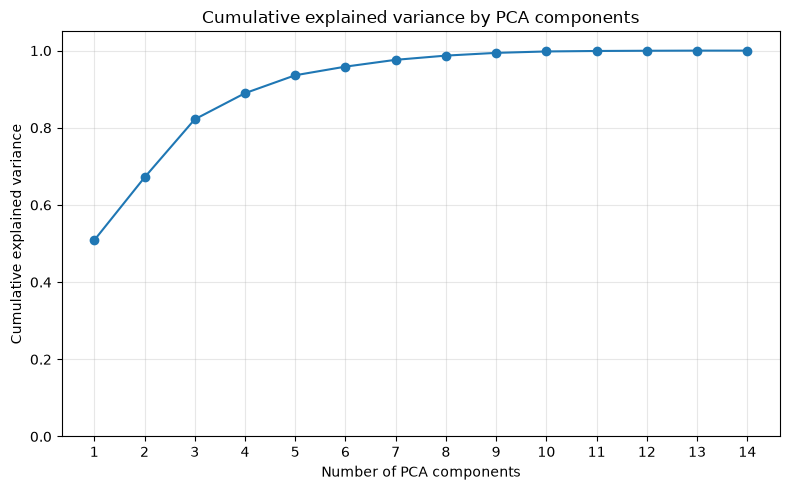

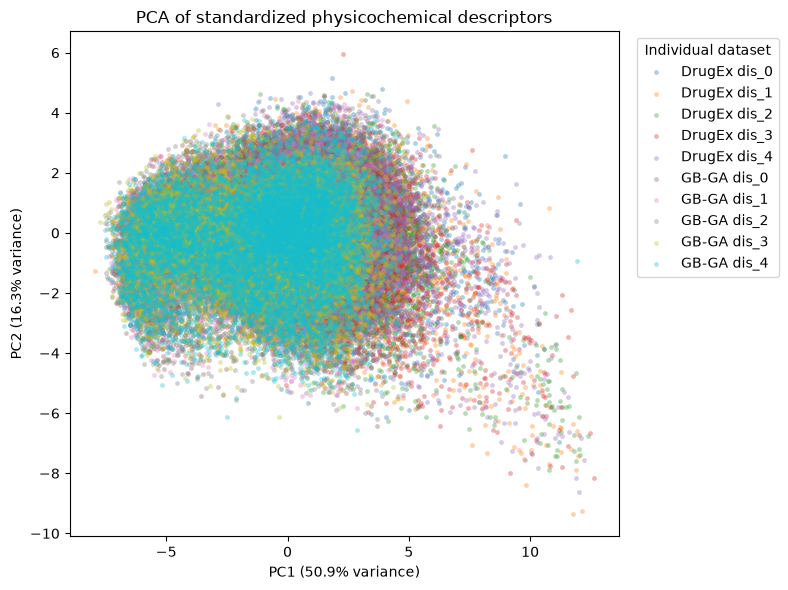

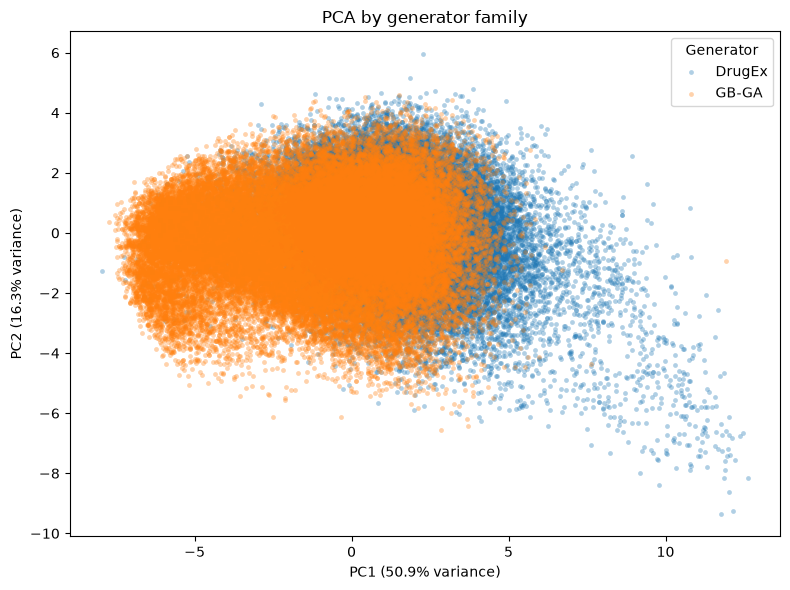

In [15]:
X_descriptors = generated[descriptor_columns].replace([np.inf, -np.inf], np.nan)
descriptor_preprocessor = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
)
X_descriptors_scaled = descriptor_preprocessor.fit_transform(X_descriptors)

n_descriptors = len(descriptor_columns) # def smaller than n_samples so I use this instead cuz max allowed components is max(row,col)
pca = PCA(n_components=n_descriptors, random_state=RANDOM_STATE)
pca_coordinates = pca.fit_transform(X_descriptors_scaled)

explained_variance = pd.DataFrame(
    {
        "n_components": np.arange(1, n_descriptors + 1),
        "explained_variance_ratio": pca.explained_variance_ratio_,
        "cumulative_explained_variance": np.cumsum(pca.explained_variance_ratio_),
    }
)
display(explained_variance)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    explained_variance["n_components"],
    explained_variance["cumulative_explained_variance"],
    marker="o",
)
ax.set_xlabel("Number of PCA components")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("Cumulative explained variance by PCA components")
ax.set_xticks(explained_variance["n_components"])
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

dataset_names = sorted(generated["dataset"].unique())
dataset_cmap = plt.get_cmap("tab10")
dataset_colors = {
    dataset: dataset_cmap(index)
    for index, dataset in enumerate(dataset_names)
}

pca_plot = generated[["generator", "run", "dataset"]].copy()
pca_plot[["PC1", "PC2"]] = pca_coordinates[:, :2]

fig, ax = plt.subplots(figsize=(8, 6))
for dataset, group in pca_plot.groupby("dataset"):
    ax.scatter(
        group["PC1"],
        group["PC2"],
        label=dataset,
        color=dataset_colors[dataset],
        alpha=0.35,
        s=12,
        linewidths=0,
    )
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.set_title("PCA of standardized physicochemical descriptors")
ax.legend(title="Individual dataset", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()

# Joined view: combine the five runs into the two generator families.
generator_colors = {
    "DrugEx_GT_epsilon_0.6": "tab:blue",
    "GB_GA_mut_r_0.5": "tab:orange",
}

fig, ax = plt.subplots(figsize=(8, 6))
for generator, group in pca_plot.groupby("generator"):
    ax.scatter(
        group["PC1"],
        group["PC2"],
        label=generator_short_names[generator],
        color=generator_colors[generator],
        alpha=0.35,
        s=12,
        linewidths=0,
    )
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.set_title("PCA by generator family")
ax.legend(title="Generator")
fig.tight_layout()
plt.show()


## t-SNE

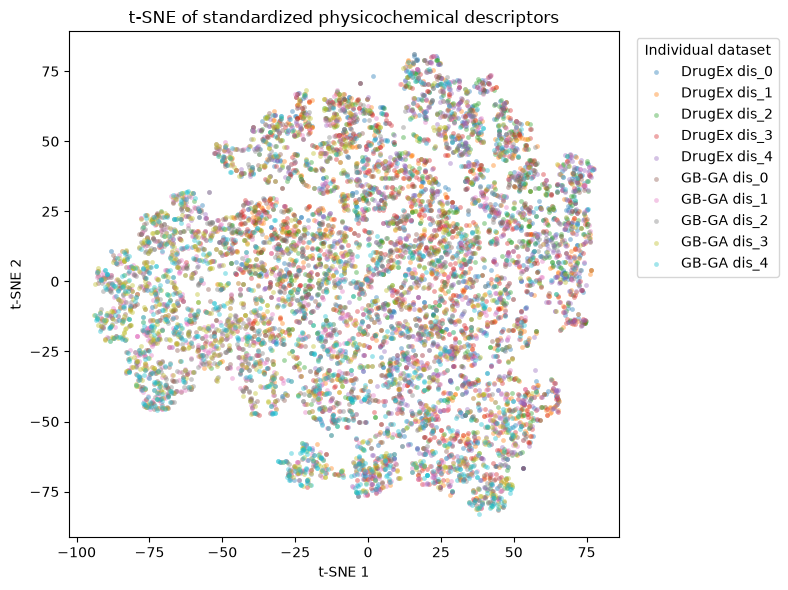

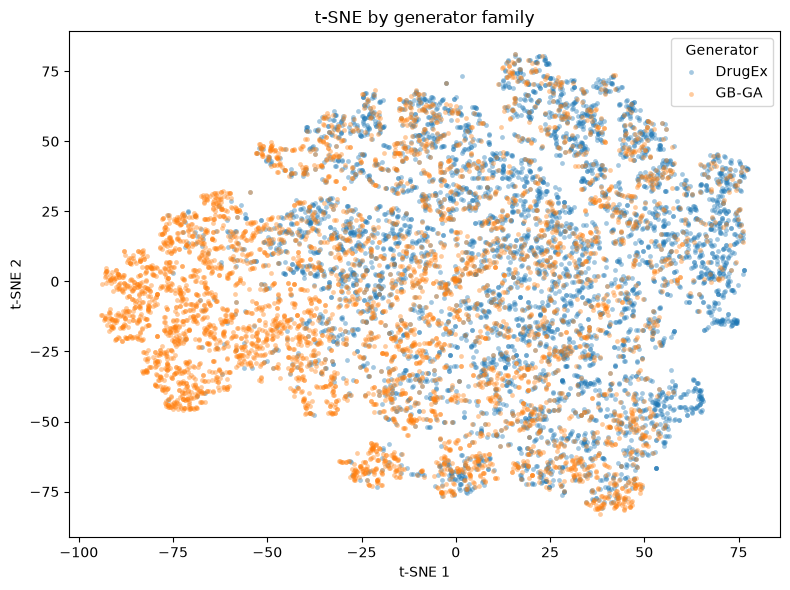

In [16]:
# Use an equal-sized sample from every individual input dataset.
TSNE_SAMPLES_PER_DATASET = 1_000

tsne_sample = (
    generated.groupby("dataset", group_keys=False)
    .sample(n=TSNE_SAMPLES_PER_DATASET, random_state=RANDOM_STATE)
    .sort_index()
)
X_tsne = X_descriptors_scaled[tsne_sample.index.to_numpy()]

tsne = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    random_state=RANDOM_STATE,
)
tsne_coordinates = tsne.fit_transform(X_tsne)

tsne_plot = tsne_sample[["generator", "run", "dataset"]].reset_index(drop=True)
tsne_plot[["tSNE1", "tSNE2"]] = tsne_coordinates

fig, ax = plt.subplots(figsize=(8, 6))
for dataset, group in tsne_plot.groupby("dataset"):
    ax.scatter(
        group["tSNE1"],
        group["tSNE2"],
        label=dataset,
        color=dataset_colors[dataset],
        alpha=0.4,
        s=12,
        linewidths=0,
    )
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_title("t-SNE of standardized physicochemical descriptors")
ax.legend(title="Individual dataset", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
plt.show()

# Joined view: combine the five runs into the two generator families.
fig, ax = plt.subplots(figsize=(8, 6))
for generator, group in tsne_plot.groupby("generator"):
    ax.scatter(
        group["tSNE1"],
        group["tSNE2"],
        label=generator_short_names[generator],
        color=generator_colors[generator],
        alpha=0.4,
        s=12,
        linewidths=0,
    )
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_title("t-SNE by generator family")
ax.legend(title="Generator")
fig.tight_layout()
plt.show()
